# Visualization and statistical analysis

- Inclusive count: cells positive in any of the channel combination, then it is positive for this combination of channels.
- Exclusive count: cells positive in all of the channel combination, then it is positive for this combination of channels and is associated to this category.

Save the results as a 'destination folder/*-stats.csv' file

Define the result folder

In [1]:
import yaml
from pathlib import Path
from ipyfilechooser import FileChooser
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import tifffile
from PIL import Image

srcdir, dstdir = "", ""
if Path("config.yml").exists():
    with open("config.yml", "r") as file:
        config = yaml.safe_load(file)
        if "source" in config.keys():
            srcdir = Path(config["source"])
        if "destination" in config.keys():
            dstdir = Path(config["destination"])

fc = FileChooser(dstdir, select_desc="Destination")
display(fc)

FileChooser(path='C:\Users\Amy Courtney\Documents\Temp\Marie_HCR_Test\Full_Size', filename='', title='', show_…

In [2]:
import pandas as pd

dstdir = Path(fc.selected) if fc.selected is not None else Path(dstdir)
filelistname = dstdir / "filelist.csv"
filelist = pd.read_csv(filelistname)
filelist

,folder,name,channel1,channel2,channel3,channel4
0,C:\Users\Amy Courtney\Documents\Temp\Marie_HCR...,3-01-Stitching-26.ims,vacht,vglut,Cell_Label,nuclei
1,C:\Users\Amy Courtney\Documents\Temp\Marie_HCR...,4-01-Stitching-06.ims,vacht,vglut,Cell_Label,nuclei
2,C:\Users\Amy Courtney\Documents\Temp\Marie_HCR...,5-01-Stitching-16.ims,vacht,vglut,Cell_Label,nuclei


In [4]:
from itertools import chain, combinations
from functools import partial
from functools import reduce
import operator
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import napari
import dask


def get_files(dstdir, row, key=None):
    if key == "ims":
        return Path(row["folder"]) / row["name"]
    elif key == "regions":
        return Path(dstdir / str(row["name"]).replace(".ims", "-regions.json"))
    elif key == "labels":
        return Path(dstdir / str(row["name"]).replace(".ims", "-labels.tif"))
    elif key == "measurements":
        return Path(dstdir / str(row["name"]).replace(".ims", "-measurements.csv"))
    elif key == "stats":
        return Path(dstdir / str(row["name"]).replace(".ims", "-stats.csv"))
    else:
        return {
            "ims": get_files(dstdir, row, "ims"),
            "regions": get_files(dstdir, row, "regions"),
            "labels": get_files(dstdir, row, "labels"),
            "measurements": get_files(dstdir, row, "measurements"),
        }


def get_measurement_channels(df):
    """List the channels name from the measurement data"""
    return df.columns[6:]


def create_heatmaps(labels, df):
    channel_columns = [f"c{k}" for k in range(10) if f"c{k}" in df.columns]

    heatmaps = np.zeros([len(channel_columns), *labels.shape])
    for row in df.iloc:
        for k, c in enumerate(channel_columns):
            heatmaps[k][labels == row["label"]] = row[c]
    return heatmaps


def madstd(x):
    """Median std"""
    return 1.48 * np.median(np.abs(x - np.median(x)))


def powerset(iterable):
    """Compute the powerset of iterable"""
    s = list(iterable)
    return chain.from_iterable(combinations(s, r) for r in range(len(s) + 1))


def encode(row, channels, thresholds, encoder):
    """compute a code from the channels columns and the tresholds"""
    t = tuple([c for c in channels if row[c] > thresholds[c]])
    return encoder[t]


def encode_channels_exclusive(df, columns, thresholds):
    """Encode the channel in the data frame based on intensity

    Parameters
    ----------
    df : pd.DataFrame
    columns : List[str]
        list of columns names
    thresholds: List[float]
        list of threshold values

    Returns
    -------
    code_df and encoder, decoder dicts
    """
    pset = [x for x in powerset(columns)]
    encoder = {x: k for k, x in enumerate(pset)}
    decoder = {k: x for k, x in enumerate(pset)}
    decoder[0] = ("none",)
    decode_str = {
        a: b
        for a, b in enumerate(["+".join([str(e) for e in k]) for k in encoder.keys()])
    }
    cid = df.apply(
        partial(encode, channels=columns, encoder=encoder, thresholds=thresholds),
        axis=1,
    )
    code_df = pd.DataFrame({"label": df["label"], "id": cid})
    return code_df, decoder


def prod(iterable):
    return reduce(operator.mul, iterable, 1)


def encode_channels_inclusive(df, columns, thresholds):
    """Encode the channel in the data frame based on intensity

    Parameters
    ----------
    df : pd.DataFrame
    channels : List[str]
        list of channel names
    thresholds: List[float]
        list of threshold values

    Returns
    -------

    code_df and encoder, decoder dicts
    """
    pset = [x for x in powerset(columns)]
    decoder = {k + 1: "+".join([str(e) for e in x]) for k, x in enumerate(pset[1:])}
    code_df = pd.DataFrame(
        {
            "+".join([str(e) for e in k]): prod([df[e] > thresholds[e] for e in k])
            for k in pset[1:]
        }
    )
    code_df["label"] = df["label"]
    return code_df, decoder

def create_class_image(labels, codes, decoder, chunk_size=20):
    """Create a map of the binary codes as a label map

    Parameter
    ---------
    labels: np.array

    codes: pd.DataFrame
        data frame with a column label and a label code

    decoder: dict
        dictionary: {id: tuple(combination columns names)}

    Note add 1 to the code so that it is not set to background
    """
    def helper(stack, labels, codes, decoder):
        for row in codes.iloc:
            stack[labels == row["label"]] = row["id"] + 1
    
    stack = np.zeros(labels.shape, dtype=np.uint8)

    tsk = [
        dask.delayed(helper)(
            stack, labels, codes.iloc[n : n + chunk_size], decoder
        )
        for n in range(0, codes.shape[0], chunk_size)
    ]
    
    dask.compute(tsk)

    features = pd.DataFrame(
        {"code": ["background", *[" + ".join(decoder[k]) for k in decoder]]}
    )
    return stack, features

def create_class_masks(labels, codes, decoder, chunk_size=20):
    """Create a set of maps for each combination of labels

    Parameter
    ---------
    labels: np.array

    codes: pd.DataFrame
        data frame with a column label and a column per combination

    decoder: dict
        dictionary: {id: tuple(combination columns names)}

    """
    nc = len(decoder)
    stack = np.zeros([nc, *labels.shape], dtype=np.uint8)

    def helper(stack, labels, codes, decoder):
        for row in codes.iloc:
            for c in decoder:
                if row[decoder[c]] == 1:
                    stack[c - 1][labels == row["label"]] = 255

    tsk = [
        dask.delayed(helper)(
            stack, labels, codes.iloc[n : n + chunk_size], decoder
        )
        for n in range(0, codes.shape[0], chunk_size)
    ]

    dask.compute(tsk)
    names = [decoder[k] for k in decoder]
    return stack, names


def aggregate_combinations(input, decoder):
    """Aggregate the inputs based on combinations in the decoder

    Parameters
    ----------
    input: pd.DataFrame or np.array
        input on which to compute the aggregation
    decoder: dict
        mapping between keys of the input and the corresponding set of channels
    """
    output = input.copy()
    for k1 in decoder:
        for k2 in decoder:
            if len(decoder[k2]) > len(decoder[k1]):
                for y1 in decoder[k1]:
                    if y1 in decoder[k2]:
                        output[k1] = output[k1] + input[k2]
    return output

def map_intensity(labels, df, channels, chunk_size=20):
    """Set each label with the intensity store in the dataframe df

    The purpose of this is to help ind the adequate threshold

    Parameters
    ----------
    labels: ndarray (D,H,W)
        labels of the segmented nuclei in 3D
    df: pd.dataframe
        data frame with intensity measurement and matching labels indices
    channels: List
        list of the channels
    chunk_size: int
        size of the chunck

    Return
    ------
    map : ndarray (C,D,H,W)
        intensity map for each label
    """
    
    def helper(dst, labels, df, channels):
        for row in df.iloc:
            idx = labels == row["label"]
            for k, ch in enumerate(channels):
                dst[k][idx] = row[ch]

    dst = np.zeros((len(channels), *labels.shape))
    tsk = [
        dask.delayed(helper)(
            dst, labels, df.iloc[n : n + chunk_size], channels
        )
        for n in range(0, df.shape[0], chunk_size)
    ]
    dask.compute(tsk)

    return dst

In [46]:
import ipywidgets as widgets

w = widgets.Dropdown(
    options=[(x, k) for k, x in enumerate(filelist["name"])],
    value=1,
    description="Image:",
)
display(w)

Dropdown(description='Image:', index=1, options=(('3-01-Stitching-26.ims', 0), ('4-01-Stitching-06.ims', 1), (…

In [47]:
Image_Name = '5-01-Stitching-16'
save_folder = 'C:/Users/Amy Courtney/Documents/Temp/Marie_HCR_Test/Full_Size/3-01-Stitching-26_Results'

In [48]:
from imaris_ims_file_reader.ims import ims

row = filelist.iloc[w.value]
resolution_level = 1  # need to be the same than the one used for processing
img = ims(get_files(dstdir, row, "ims"), ResolutionLevelLock=resolution_level)

Opening readonly file: C:\Users\Amy Courtney\Documents\Temp\Marie_HCR_Test\Full_Size\5-01-Stitching-16.ims 

Closing file: C:\Users\Amy Courtney\Documents\Temp\Marie_HCR_Test\Full_Size\4-01-Stitching-06.ims 



In [49]:
df = pd.read_csv(get_files(dstdir, row, "measurements"), index_col=0)
df = pd.DataFrame(df.to_records())
df

,label,roi,x,y,z,area,vacht,vglut,Cell_Label
0,1,0.0,1251.117783,14.031409,1.538106,2165,0.006500,0.026158,0.037722
1,2,0.0,1283.275522,17.018526,1.477335,2537,0.010887,0.022946,0.019106
2,3,0.0,1309.347147,16.785791,1.603875,1858,0.047796,0.005413,0.125305
3,4,0.0,1399.422787,13.823917,1.367232,1062,0.009980,0.008256,0.231135
4,5,0.0,1515.722513,13.391361,1.371728,764,0.032330,0.039860,0.023712
...,...,...,...,...,...,...,...,...,...
1983,1984,2.0,1087.014825,517.712938,3.000000,742,0.128794,0.071019,0.004913
1984,1985,2.0,1443.013333,552.697143,3.000000,525,0.244483,0.052471,0.000000
1985,1986,3.0,1468.441683,704.185468,3.000000,523,0.068183,0.000000,0.006645
1986,1987,0.0,715.068226,840.869396,3.000000,513,0.002288,0.046132,0.000000


In [50]:
labels = tifffile.imread(get_files(dstdir, row, "labels"))

df = pd.read_csv(get_files(dstdir, row, "measurements"), index_col=0)
df = pd.DataFrame(df.to_records())

channels = get_measurement_channels(df)

In [51]:
cell_intensity = map_intensity(labels, df, channels)

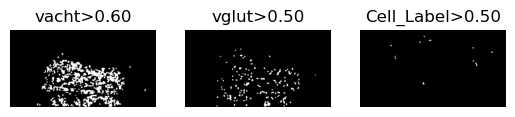

In [54]:
# default thresholds
thresholds = {c: df[c].median() + 0.5 * madstd(df[c]) for c in channels}
# custom threshold
thresholds = {"vacht": 0.6, "vglut": 0.5, "Cell_Label": 0.5}


fig, ax = plt.subplots(1, len(channels))
for k, ch in enumerate(channels):
    ax[k].imshow(
        cell_intensity[k, cell_intensity.shape[1] // 2] > thresholds[ch], cmap="gray"
    )
    ax[k].set_axis_off()
    ax[k].set_title(f"{ch}>{thresholds[ch]:.2f}")

C:\Users\Amy Courtney\AppData\Local\Temp\ipykernel_24888\493892656.py:7: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  codes_in.merge(df[["label", "roi"]], on="label")


,Cell_Label,vacht,vacht+Cell_Label,vacht+vglut,vacht+vglut+Cell_Label,vglut,vglut+Cell_Label
roi,,,,,,,
0.0,0.997009,25.024925,0.000000,2.891326,0.000000,8.773679,0.099701
1.0,0.374532,0.000000,0.000000,0.000000,0.000000,1.123596,0.000000
2.0,0.000000,24.166667,0.000000,2.500000,0.000000,11.666667,0.000000
3.0,0.167224,65.217391,0.167224,7.023411,0.167224,13.377926,0.167224


C:\Users\Amy Courtney\AppData\Local\Temp\ipykernel_24888\493892656.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_tbl['ROI'] = filtered_tbl['ROI'].astype(str)  # Ensure ROI column is treated as string for mapping
C:\Users\Amy Courtney\AppData\Local\Temp\ipykernel_24888\493892656.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_tbl['ROI'] = filtered_tbl['ROI'].map(roi_recode)


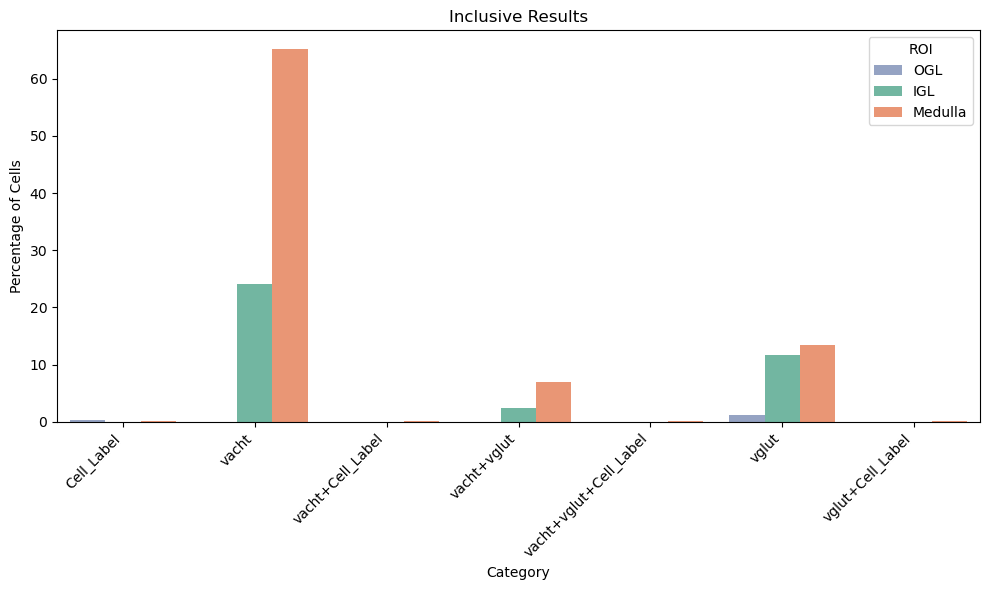

In [55]:
codes_in, decoder_in = encode_channels_inclusive(df, channels, thresholds)
codes_ex, decoder_ex = encode_channels_exclusive(df, channels, thresholds)

#inital barplt threshold check - inclusive
# Your original data processing code to create tbl_in
tbl_in = (
    codes_in.merge(df[["label", "roi"]], on="label")
    .drop(columns=["label"])
    .groupby("roi")  # group per roi
    .agg(["count", "sum"])  # count cell and positive cells
    .groupby(axis=1, level=0)  # group per category
    .apply(lambda df: 100 * df[df.columns[1]] / df[df.columns[0]])  # ratio
)
display(tbl_in)

#tbl in bar plot all
tbl_in_transposed = tbl_in.T
tbl_long = tbl_in_transposed.reset_index().melt(id_vars=['index'], var_name='ROI', value_name='Percentage')
filtered_tbl = tbl_long[tbl_long['ROI'] != 0]

# Change ROI values using map function
roi_recode = {"1.0": "OGL", "2.0": "IGL", "3.0": "Medulla"}
filtered_tbl['ROI'] = filtered_tbl['ROI'].astype(str)  # Ensure ROI column is treated as string for mapping
filtered_tbl['ROI'] = filtered_tbl['ROI'].map(roi_recode)
# Rename 'index' column to 'category'
filtered_tbl = filtered_tbl.rename(columns={'index': 'Category'})

# Plotting the grouped bar plot (side-by-side)
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Percentage', hue='ROI', data=filtered_tbl,
            palette={'OGL': '#8da0cb', 'IGL': '#66c2a5', 'Medulla': '#fc8d62'})  # Specify colors

plt.title('Inclusive Results')
plt.xlabel('Category')
plt.ylabel('Percentage of Cells')
plt.xticks(rotation=45, ha='right')
plt.legend(title='ROI')

plt.tight_layout()
plt.show()

In [56]:
maps, names = create_class_masks(labels, codes_in, decoder_in)
codes_in=codes_in.merge(df[['label','roi']])
display(codes_in)

,vacht,vglut,Cell_Label,vacht+vglut,vacht+Cell_Label,vglut+Cell_Label,vacht+vglut+Cell_Label,label,roi
0,0,0,0,0,0,0,0,1,0.0
1,0,0,0,0,0,0,0,2,0.0
2,0,0,0,0,0,0,0,3,0.0
3,0,0,0,0,0,0,0,4,0.0
4,0,0,0,0,0,0,0,5,0.0
...,...,...,...,...,...,...,...,...,...
1983,0,0,0,0,0,0,0,1984,2.0
1984,0,0,0,0,0,0,0,1985,2.0
1985,0,0,0,0,0,0,0,1986,3.0
1986,0,0,0,0,0,0,0,1987,0.0


In [57]:
#just checking thresholding with napari
v = napari.view_image(
    img, channel_axis=1, name=[row[f"channel{k+1}"] for k in range(img.shape[1])]
)
v.add_image(maps,channel_axis=0,name=names) # inclusive

[<Image layer 'vacht [1]' at 0x259aa8eff10>,
 <Image layer 'vglut [1]' at 0x2599e58e380>,
 <Image layer 'Cell_Label [1]' at 0x2599e5e3550>,
 <Image layer 'vacht+vglut' at 0x2599ec5fd60>,
 <Image layer 'vacht+Cell_Label' at 0x2599e4487c0>,
 <Image layer 'vglut+Cell_Label' at 0x2598d9f0100>,
 <Image layer 'vacht+vglut+Cell_Label' at 0x259bd410a60>]

In [49]:
# Open napari with raw image
v = napari.view_image(
    img, channel_axis=1, name=[row[f"channel{k+1}"] for k in range(img.shape[1])]
)

# Add your code maps or thresholded binary maps
v.add_image(maps, channel_axis=0, name=names)

# Add the label image (each cell = unique color)
v.add_labels(labels, name='cell_labels')


<Labels layer 'cell_labels' at 0x14b6a291a80>

In [33]:
#Inclusive regional maps

def create_all_labels_mask(labels, codes):
    mask_shape = labels.shape  # Assuming labels is a 3D array
    all_labels_mask = np.zeros(mask_shape, dtype=int)
    for label in codes['label']:
        all_labels_mask[labels == label] = 1
    return all_labels_mask

def create_class_masks(labels, codes, decoder, chunk_size=20):
    """Create a set of maps for each combination of labels

    Parameter
    ---------
    labels: np.array

    codes: pd.DataFrame
        data frame with a column label and a column per combination

    decoder: dict
        dictionary: {id: tuple(combination columns names)}

    """
    nc = len(decoder)
    stack = np.zeros([nc, *labels.shape], dtype=np.uint8)

    def helper(stack, labels, codes, decoder):
        for row in codes.iloc:
            for c in decoder:
                if row[decoder[c]] == 1:
                    stack[c - 1][labels == row["label"]] = 255

    tsk = [
        dask.delayed(helper)(
            stack, labels, codes.iloc[n : n + chunk_size], decoder
        )
        for n in range(0, codes.shape[0], chunk_size)
    ]

    dask.compute(tsk)
    names = [decoder[k] for k in decoder]
    return stack, names

# ROI name mapping
#just OGL
roi_names = {1.0: 'OGL', 2.0: 'IGL', 3.0: 'Medulla'}
roi_colors = {1.0: [141, 160, 203], 2.0: [102, 194, 165], 3.0: [252, 141, 98]}  # Colors in BGR format
#mid
#roi_names = {1.0: 'OGL', 2.0: 'IGL', 3.0: 'Medulla', 4.0:'SEM',5.0: 'SUB'}
#roi_colors = {1.0: [141, 160, 203], 2.0: [102, 194, 165], 3.0: [252, 141, 98],4.0: [231,138,195],5.0: [166,216,84]}  # Colors in BGR format
#eye
#roi_names = {1.0: 'Photoreceptors', 2.0: 'Optic Lobe'}
#roi_colors = {1.0: [175,141,195], 2.0: [127,191,123]}  # Colors in BGR format



# Loop over each unique ROI
for r in sorted(codes_in['roi'].unique()):
    if r > 0:
        # Create the all-inclusive mask
        all_labels_mask = create_all_labels_mask(labels, codes_in[codes_in['roi'] == r])
        max_proj_all_labels = np.amax(all_labels_mask, axis=0)
        max_proj_all_labels = cv2.normalize(max_proj_all_labels, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
        
        # Convert the all-inclusive mask to a consistent shade of gray
        gray_value = 127
        max_proj_all_labels[max_proj_all_labels == 255] = gray_value
        
        # Change the background to white
        all_labels_mask_color = np.full((*max_proj_all_labels.shape, 3), 255, dtype=np.uint8)
        all_labels_mask_color[max_proj_all_labels == gray_value] = gray_value
        
        # Save the all-inclusive mask as TIFF
        filename_base_all = f"Inclusive_{Image_Name}_All_Nuclei_{roi_names.get(r, f'ROI {r}')}"
        tiff_filename_all = os.path.join(save_folder, f"{filename_base_all}.tiff")
        tifffile.imsave(tiff_filename_all, all_labels_mask_color.astype(np.uint8))
        
        maps_r, names = create_class_masks(labels, codes_in[codes_in['roi'] == r], decoder_in)
        
        # Loop through each mask and corresponding name
        for k in range(len(names)):
            # Create the maximum projection of the mask without downsampling
            max_proj = np.amax(maps_r[k], axis=0)
            max_proj = cv2.normalize(max_proj, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
            
            # Convert to grayscale and replace white pixels with appropriate color
            max_proj_color = np.full((*max_proj.shape, 3), 255, dtype=np.uint8)
            white_pixels = (max_proj == 255)
            
            color = roi_colors.get(r, [0, 0, 0])  # Default to black if no matching ROI
            max_proj_color[white_pixels] = color
            
            # Create a blended image with the all-inclusive mask as background and the mask as foreground
            blend = all_labels_mask_color.copy()
            blend[white_pixels] = color
            
            # Set the title with the name and ROI
            roi_name = roi_names.get(r, f'ROI {r}')
            title = f'Inclusive: {names[k]} - {roi_name}'

            # Save the individual mask image with high resolution
            filename_base = f"Inclusive_{Image_Name}_{names[k]}_{roi_name}"
            tiff_filename = os.path.join(save_folder, f"{filename_base}.tiff")
            tifffile.imsave(tiff_filename, max_proj_color.astype(np.uint8))

            # Save the blended image with high resolution
            blended_filename = os.path.join(save_folder, f"{filename_base}_Blended.tiff")
            tifffile.imsave(blended_filename, blend.astype(np.uint8))

C:\Users\Amy Courtney\AppData\Local\Temp\ipykernel_28752\2746318806.py:76: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(tiff_filename_all, all_labels_mask_color.astype(np.uint8))
C:\Users\Amy Courtney\AppData\Local\Temp\ipykernel_28752\2746318806.py:104: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(tiff_filename, max_proj_color.astype(np.uint8))
C:\Users\Amy Courtney\AppData\Local\Temp\ipykernel_28752\2746318806.py:108: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(blended_filename, blend.astype(np.uint8))


In [34]:
#Exclusive - run for all channels
codemaps, features = create_class_image(labels, codes_ex, decoder_ex)
codes_ex=codes_ex.merge(df[['label','roi']])
#display(codes_ex)

In [ ]:
#Exclusive - run to exclude a channel
channels_to_keep=['DopC1','GPCR2']
codes_ex, decoder_ex=encode_channels_exclusive(df, channels_to_keep, thresholds) 
codemaps, features = create_class_image(labels, codes_ex, decoder_ex)
codes_ex=codes_ex.merge(df[['label','roi']])
#display(codes_ex)

In [35]:
v = napari.view_image(
    img, channel_axis=1, name=[row[f"channel{k+1}"] for k in range(img.shape[1])]
)
v.add_labels(codemaps) # exclusive (categories)
v.add_image(maps,channel_axis=0,name=names) # inclusive

[<Image layer 'vacht [1]' at 0x14b61e80f10>,
 <Image layer 'vglut [1]' at 0x14b66965cc0>,
 <Image layer 'Cell_Label [1]' at 0x14b6698f640>,
 <Image layer 'vacht+vglut' at 0x14b66930280>,
 <Image layer 'vacht+Cell_Label' at 0x14b669de6b0>,
 <Image layer 'vglut+Cell_Label' at 0x14b61e82ad0>,
 <Image layer 'vacht+vglut+Cell_Label' at 0x14b66a4ed70>]

In [ ]:
#export Inclusive and exclusive maps from napari viewer
# Set the order of the 'Category' based on the decoder_ex keys
category_order =["+".join(decoder_ex[k]) for k in range(4)]#change this to 4 if 2 channels, keep 8 if 3 channels

# Define color mappings in RGB format with color names
color_mappings = {
    5: {'color': (0, 255, 255), 'name': 'cyan'},
    6: {'color': (255, 255, 0), 'name': 'yellow'},
    7: {'color': (255, 0, 255), 'name': 'magenta'},
    8: {'color': (0, 255, 0), 'name': 'green'},
    9: {'color': (0, 0, 255), 'name': 'blue'},
    10: {'color': (255, 0, 0), 'name': 'red'},
    11:{'color': (128, 128, 128), 'name': 'gray'}
}

if os.path.isdir(save_folder):
    # Retrieve and print the names of all layers
    layer_names = [layer.name for layer in v.layers]
    print("Layer names:", layer_names)

    # Save each layer and its MIP as TIFF files
    for layer_index, layer_name in enumerate(layer_names):
        layer = v.layers[layer_name]
        print(f"Processing layer {layer_index}: {layer_name}")

        filename = os.path.join(save_folder, f"{Image_Name}_{layer_name}.tif")
        tifffile.imsave(filename, layer.data)
        print(f"Saved {layer_name} as {filename}")

        # Calculate and save the maximum intensity projection (MIP)
        mip = np.max(layer.data, axis=0)
        mip_rescaled = cv2.normalize(mip, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
        mip_filename = os.path.join(save_folder, f"{Image_Name}_{layer_name}_MIP.tif")
        tifffile.imsave(mip_filename, mip_rescaled.astype(np.uint8))
        print(f"Saved rescaled MIP of {layer_name} as {mip_filename}")

        # Apply color conversion based on layer_index
        if layer_index in color_mappings:
            print(f"Processing color conversion for layer {layer_name}")
            color_info = color_mappings[layer_index]
            color = color_info['color']
            color_name = color_info['name']
            white_pixels = (mip_rescaled == 255)
            print(f"Found {np.sum(white_pixels)} white pixels in MIP of layer {layer_name}")
            if np.sum(white_pixels) > 0:
                # Create a 3-channel image with the same height and width as the MIP
                color_image = np.zeros((mip_rescaled.shape[0], mip_rescaled.shape[1], 3), dtype=np.uint8)
                # Apply the mask to each channel
                color_image[white_pixels, 0] = color[0]
                color_image[white_pixels, 1] = color[1]
                color_image[white_pixels, 2] = color[2]
                color_filename = os.path.join(save_folder, f"{Image_Name}_{layer_name}_MIP_{color_name}.tif")
                tifffile.imsave(color_filename, color_image)
                print(f"Saved {color_name} image of MIP of {layer_name} as {color_filename}")
            else:
                print(f"No white pixels found for MIP of layer {layer_name} to convert to {color_name}.")

        # If the layer is 'codemaps', save each label separately and its MIP
        if layer_name == 'codemaps':
            unique_labels = np.unique(layer.data)
            unique_labels = unique_labels[unique_labels != 0]  # Remove the first codemap label (0)
            for label in unique_labels:
                print(f"Processing label {label} for {layer_name}")
                label_data = (layer.data == label).astype(np.uint8)
                category_name = category_order[label - 1]
                label_filename = os.path.join(save_folder, f"{Image_Name}_{layer_name}_label_{label}_{category_name}.tif")
                tifffile.imsave(label_filename, label_data)
                print(f"Saved label {label} of {layer_name} as {label_filename}")

                # Calculate and save the MIP for each label
                label_mip = np.max(label_data, axis=0)
                # Rescale the MIP to 255 for white pixels
                label_mip_rescaled = cv2.normalize(label_mip, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
                label_mip_filename = os.path.join(save_folder, f"{Image_Name}_{layer_name}_label_{label}_{category_name}_MIP.tif")
                tifffile.imsave(label_mip_filename, label_mip_rescaled.astype(np.uint8))
                print(f"Saved rescaled MIP of label {label} of {layer_name} as {label_mip_filename}")

else:
    print("Invalid folder path. Exiting without saving files.")

In [ ]:
#inclusive napari maps continued - blending
def blend_images_with_background(save_folder, color_mappings):
    # Find the background image ending with 'codemaps_MIP.tif'
    background_path = None
    for file in os.listdir(save_folder):
        if file.endswith('codemaps_MIP.tif'):
            background_path = os.path.join(save_folder, file)
            break
    
    if not background_path:
        print("Background image 'codemaps_MIP.tif' not found in the specified folder.")
        return

    # Load the background (first) image and convert to RGBA
    background_img = Image.open(background_path).convert('RGBA')

    # Convert grayscale pixels (excluding black and white) to white
    for x in range(background_img.width):
        for y in range(background_img.height):
            pixel = background_img.getpixel((x, y))
            if pixel[:3] != (0, 0, 0) and pixel[:3] != (255, 255, 255):  # Check if not black or white pixel
                gray_value = sum(pixel[:3]) / 3
                if gray_value > 0 and gray_value < 255:  # Check if grayscale
                    background_img.putpixel((x, y), (255, 255, 255, pixel[3]))  # Set pixel to white

    # Get all files in the folder ending with color names defined in color_mappings
    overlay_paths = []
    for file in os.listdir(save_folder):
        for color_id, color_data in color_mappings.items():
            color_name = color_data['name']
            if file.endswith(f"{color_name}.tif"):
                overlay_paths.append(os.path.join(save_folder, file))
                break

    # Loop through overlay images
    for overlay_path in overlay_paths:
        # Load the overlay (second) image and convert to RGBA
        overlay_img = Image.open(overlay_path).convert('RGBA')

        # Resize overlay image to match background image if sizes differ
        if background_img.size != overlay_img.size:
            overlay_img = overlay_img.resize(background_img.size)

        # Ensure overlay image has transparent background (remove black pixels)
        overlay_img_no_bg = Image.new('RGBA', overlay_img.size)
        for x in range(overlay_img.width):
            for y in range(overlay_img.height):
                pixel = overlay_img.getpixel((x, y))
                if pixel[0] != 0 or pixel[1] != 0 or pixel[2] != 0:
                    overlay_img_no_bg.putpixel((x, y), pixel)

        # Extract filenames without extension
        background_filename = os.path.splitext(os.path.basename(background_path))[0]
        overlay_filename = os.path.splitext(os.path.basename(overlay_path))[0]

        # Remove duplicate occurrences of folder name from overlay filename
        overlay_filename_cleaned = overlay_filename.replace(background_filename, '').strip('_')

        # Combine filenames, avoiding duplicate words
        combined_filename = background_filename + '_' + overlay_filename_cleaned

        # Blend images
        blended_img = Image.alpha_composite(background_img, overlay_img_no_bg)

        # Save the blended image in the same folder with the combined filename
        save_path = os.path.join(save_folder, combined_filename + '.tif')
        blended_img.save(save_path)

        print(f"Blended image saved as: {save_path}")

# Example usage:
blend_images_with_background(save_folder, color_mappings)

In [ ]:
#tbl inclusive - SUM
# Your original data processing code to create tbl_in
tbl_in = (
    codes_in.drop(columns=["label"])
    .groupby("roi")  # group per roi
    .agg(["count", "sum"])  # count cell and positive cells
    #.groupby(axis=1, level=0)  # group per category
    #.apply(lambda df: 100 * df[df.columns[1]] / df[df.columns[0]])  # ratio
)

# Save tbl_in as CSV
csv_filename = f"{save_folder}/{Image_Name}_tbl_in_SUM.csv"
tbl_in.to_csv(csv_filename)

#print(f"Saved tbl_in as {csv_filename}")
display(tbl_in)

In [ ]:
#tbl inclusive - %
# Your original data processing code to create tbl_in
tbl_in = (
    codes_in.drop(columns=["label"])
    .groupby("roi")  # group per roi
    .agg(["count", "sum"])  # count cell and positive cells
    .groupby(axis=1, level=0)  # group per category
    .apply(lambda df: 100 * df[df.columns[1]] / df[df.columns[0]])  # ratio
)

# Save tbl_in as CSV
csv_filename = f"{save_folder}/{Image_Name}_tbl_in.csv"
tbl_in.to_csv(csv_filename)

#print(f"Saved tbl_in as {csv_filename}")
display(tbl_in)

In [ ]:
tbl_ex = (
    codes_ex.groupby(["roi", "id"])
    .agg("count")
    .reset_index()
)
tbl_ex["category"] = ["+".join(decoder_ex[x]) for x in tbl_ex["id"]]
tbl_ex = tbl_ex.pivot_table(values="label", columns="category", index="roi")
tbl_ex = tbl_ex.apply(lambda x: 100 * x / x.sum(), axis=1)
tbl_ex

# Save tbl_ex as CSV
csv_filename = f"{save_folder}/{Image_Name}_tbl_ex.csv"
tbl_ex.to_csv(csv_filename)

print(f"Saved tbl_ex as {csv_filename}")
display(tbl_ex)

In [ ]:
#exclusive bar plot - OL only
tbl_ex = (
    codes_ex.groupby(["roi", "id"])
    .agg("count")
    .reset_index()
)
tbl_ex["category"] = ["+".join(decoder_ex[x]) for x in tbl_ex["id"]]
tbl_ex = tbl_ex.pivot_table(values="label", columns="category", index="roi")
tbl_ex = tbl_ex.apply(lambda x: 100 * x / x.sum(), axis=1)
tbl_ex

category_order =["+".join(decoder_ex[k]) for k in range(4)]#change 4 or 8
#tab ex bar plot all
tbl_ex_transposed = tbl_ex.T
tbl_long = tbl_ex_transposed.reset_index().melt(id_vars=['category'], var_name='ROI', value_name='Percentage')
filtered_tbl = tbl_long[tbl_long['ROI'] != 0]


# Modify the 'Percentage' column to set values below 1 to 0
filtered_tbl['Percentage'] = filtered_tbl['Percentage'].apply(lambda x: 0 if x < 1 else x)


roi_recode = {"1.0": "OGL", "2.0": "IGL", "3.0": "Medulla"}
filtered_tbl['ROI'] = filtered_tbl['ROI'].astype(str)  # Ensure ROI column is treated as string for mapping
filtered_tbl['ROI'] = filtered_tbl['ROI'].map(roi_recode)
filtered_tbl = filtered_tbl.rename(columns={'category': 'Category'})

# Plotting the grouped bar plot (side-by-side)
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Percentage', hue='ROI', data=filtered_tbl,
            palette={'OGL': '#8da0cb', 'IGL': '#66c2a5', 'Medulla': '#fc8d62'},
            order=category_order)  # Specify colors

plt.title('Exclusive Results')
plt.xlabel('')
plt.ylabel('Percentage of Cells')
plt.xticks(rotation=90)
plt.legend(title='ROI')

# Ensure the save folder exists
os.makedirs(save_folder, exist_ok=True)

# Extract base name of the imported file
file_path = os.path.join(save_folder, f"{Image_Name}_tbl_in.csv")

# Show the plot and save as PDF and TIFF
plot_filename_pdf = os.path.join(save_folder, f"{Image_Name}_Exclusive_Barplot.pdf")
plot_filename_tiff = os.path.join(save_folder, f"{Image_Name}_Exclusive_Barplot.tiff")
plt.savefig(plot_filename_pdf, format='pdf', bbox_inches='tight')
# Uncomment the next line if you want to save as TIFF
# plt.savefig(plot_filename_tiff, format='tiff', bbox_inches='tight')

print(f"Saved plot as {plot_filename_pdf}")
# print(f"Saved plot as {plot_filename_tiff}")

plt.tight_layout()
plt.show()